In [2]:
import os
import time
import joblib
import numpy as np
import polars as pl
import psutil

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# OPTUNA
import optuna

# XGBOOST
from xgboost import XGBClassifier

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================

path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

TARGET_COL = "attack_cat"

# 2. Crear y_train e y_test (Normal=1, Ataque=-1)
y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

print(f"Forma de x_train: {x_train.shape} | Clases únicas en y_train: {y_train.unique().to_list()}")
print("\nDistribución de clases en Train:")
print(y_train.value_counts())
print("\nDistribución de clases en Test:")
print(y_test.value_counts())

# Convertimos a NumPy
X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()

# Split interno (no imprescindible para CV, pero lo mantenemos como lo tenías)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full_train, y_full_train, test_size=0.2, random_state=42, stratify=y_full_train
)

X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

print(f"Entrenamiento: {X_train_np.shape[0]} muestras")
print(f"Validación:    {X_val_np.shape[0]} muestras")
print(f"Test:          {X_test_np.shape[0]} muestras")

Forma de x_train: (175341, 12) | Clases únicas en y_train: [-1, 1]

Distribución de clases en Train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ 1     ┆ 56000  │
│ -1    ┆ 119341 │
└───────┴────────┘

Distribución de clases en Test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 37000 │
│ -1    ┆ 45332 │
└───────┴───────┘
Entrenamiento: 140272 muestras
Validación:    35069 muestras
Test:          82332 muestras


In [ ]:
# ==========================================
# FASE 1 - OPTUNA + 3-FOLD CV (XGBOOST)
# Objetivos: max F1_macro, min latencia
# Hiperparámetros estructurales: n_estimators, max_depth
# ==========================================

def objective(trial):
    # 1) Sugerir hiperparámetros estructurales
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 12)  # en XGB >12 suele ser excesivo

    # 2) Configurar CV
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42) # Hemos bajado 2 folds para acelerar

    f1_scores = []
    latencies = []

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train), start=1):
        X_train_cv, X_val_cv = X_full_train[train_idx], X_full_train[val_idx]
        y_train_cv, y_val_cv = y_full_train[train_idx], y_full_train[val_idx]

        # XGBoost espera etiquetas 0/1 idealmente para binary:logistic.
        # Convertimos -1/1 -> 0/1 localmente en cada fold:
        y_train_cv01 = ((y_train_cv + 1) // 2).astype(np.int8)
        y_val_cv01   = ((y_val_cv + 1) // 2).astype(np.int8)

        # 3) Modelo XGBoost
        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,

            learning_rate=0.1, # Tasa de aprendizaje fijada

            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            
            # Aceleración del hardware
            tree_method="hist",
            device="cuda",
        )

        # 4) Entrenamiento en GPU
        model.fit(
            X_train_cv, y_train_cv01,
        )

        # 5) Inferencia en CPU para que Pareto refleje el escenario de despliegue
        model.set_params(device="cpu")

        # 6) Eficacia: F1 macro
        # predict() devuelve 0/1
        y_pred01 = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv01, y_pred01, average="macro"))

        # 7) Eficiencia: latencia en CPU
        # Warm-up
        warm_n = min(1000, len(X_val_cv))
        _ = model.predict(X_val_cv[:warm_n])

        # Medimos sobre subset fijo para que no tarde mucho y sea comparable
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]

        # Repetimos 3 veces
        rep = 3
        fold_lat = []
        for _ in range(rep):
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            fold_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(fold_lat)))

    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies))
    std_f1 = float(np.std(f1_scores))

    trial.set_user_attr("f1_std", std_f1)

    return avg_f1, avg_lat


study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="tfg_ids_xgb_optimization_cv"
)

print("🚀 Iniciando barrido multiobjetivo con XGBoost + 2-Fold CV...")
print("Nota: Cada trial entrena 2 modelos. Esto será más lento pero más robusto.")

study.optimize(objective, n_trials=50)


# ==========================================
# GUARDAR RESULTADOS A CSV (POLARS)
# ==========================================

# Ojo: mejor marcar Pareto por number (más robusto que 't in best_trials')
pareto_ids = {t.number for t in study.best_trials}

trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "max_depth": t.params["max_depth"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("xgb_trials_results_cv_sin_early.csv")

print("\n✅ Resultados robustos guardados en 'xgb_trials_results_cv_sin_early.csv'")
print(df_results.sort("f1_macro", descending=True).head())

[I 2026-02-26 22:25:32,432] A new study created in memory with name: tfg_ids_xgb_optimization_cv


🚀 Iniciando barrido multiobjetivo con XGBoost + 3-Fold CV...
Nota: Cada trial entrena 2 modelos. Esto será más lento pero más robusto.


[I 2026-02-26 22:25:41,493] Trial 0 finished with values: [0.9354731816880657, 0.001695642868677775] and parameters: {'n_estimators': 350, 'max_depth': 6}.
[I 2026-02-26 22:25:48,723] Trial 1 finished with values: [0.9343426459860134, 0.0017247212895502646] and parameters: {'n_estimators': 300, 'max_depth': 5}.
[I 2026-02-26 22:26:10,465] Trial 2 finished with values: [0.9355445960235186, 0.0011593048616002004] and parameters: {'n_estimators': 400, 'max_depth': 10}.
[I 2026-02-26 22:26:26,453] Trial 3 finished with values: [0.935508963261922, 0.0015735497387746968] and parameters: {'n_estimators': 550, 'max_depth': 6}.
[I 2026-02-26 22:26:58,795] Trial 4 finished with values: [0.9352191681241266, 0.0018849688737342754] and parameters: {'n_estimators': 600, 'max_depth': 11}.
[I 2026-02-26 22:27:07,754] Trial 5 finished with values: [0.9353911784126894, 0.0015302178294708331] and parameters: {'n_estimators': 300, 'max_depth': 6}.
[I 2026-02-26 22:27:12,246] Trial 6 finished with values: 


✅ Resultados robustos guardados en 'xgb_trials_results_cv_sin_early.csv'
shape: (5, 6)
┌──────────────┬───────────┬──────────┬──────────┬────────────┬───────────┐
│ n_estimators ┆ max_depth ┆ f1_macro ┆ f1_std   ┆ latency_ms ┆ is_pareto │
│ ---          ┆ ---       ┆ ---      ┆ ---      ┆ ---        ┆ ---       │
│ i64          ┆ i64       ┆ f64      ┆ f64      ┆ f64        ┆ bool      │
╞══════════════╪═══════════╪══════════╪══════════╪════════════╪═══════════╡
│ 350          ┆ 8         ┆ 0.936456 ┆ 0.000723 ┆ 0.001417   ┆ false     │
│ 350          ┆ 8         ┆ 0.936456 ┆ 0.000723 ┆ 0.001048   ┆ true      │
│ 500          ┆ 8         ┆ 0.935873 ┆ 0.001041 ┆ 0.001769   ┆ false     │
│ 500          ┆ 6         ┆ 0.935733 ┆ 0.000577 ┆ 0.001735   ┆ false     │
│ 250          ┆ 10        ┆ 0.935713 ┆ 0.000726 ┆ 0.001755   ┆ false     │
└──────────────┴───────────┴──────────┴──────────┴────────────┴───────────┘


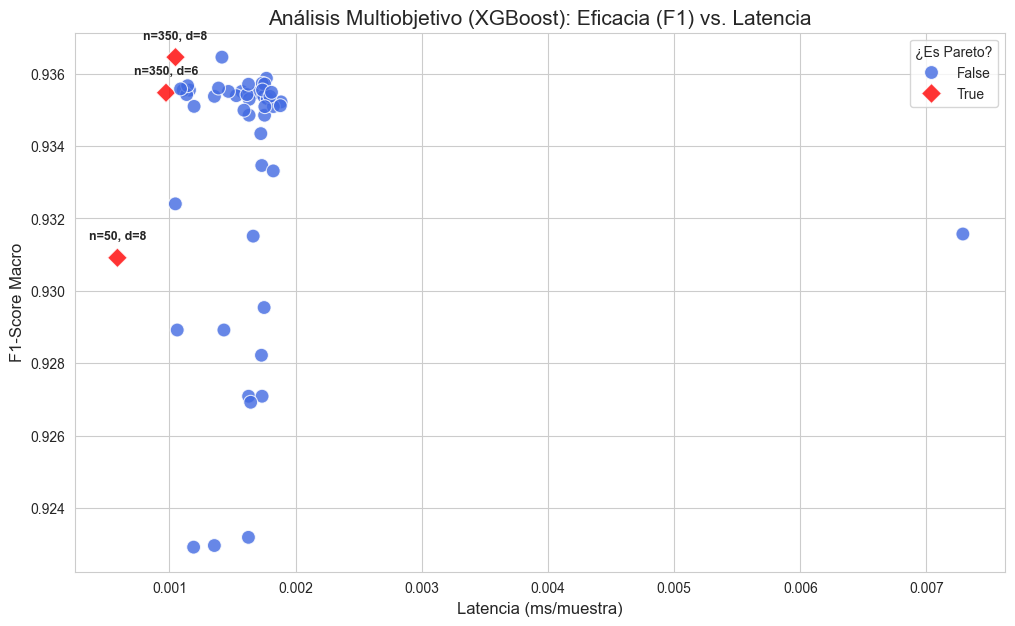

In [4]:
# ==========================================
# GRAFICA PARETO (Polars + NumPy Edition)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

df = pl.read_csv("xgb_trials_results_cv_sin_early.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_macro"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        fontsize=9, fontweight='bold', ha='center'
    )

plt.title("Análisis Multiobjetivo (XGBoost): Eficacia (F1) vs. Latencia", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


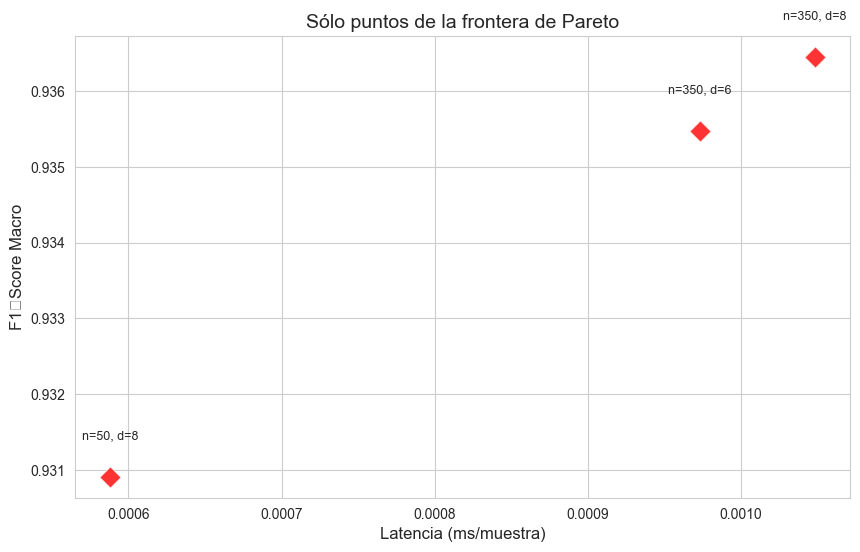

In [5]:
# AHORA SOLO REPRESENTAMOS LOS MODELOS DE LA FRONTERA DE PARETO

df = pl.read_csv("xgb_trials_results_cv_sin_early.csv")
pareto_df = df.filter(pl.col("is_pareto") == True)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.8
)

for row in pareto_df.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        fontsize=9,
        ha="center"
    )

plt.title("Sólo puntos de la frontera de Pareto", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1‑Score Macro", fontsize=12)
plt.show()



In [8]:
# ==========================================
# EVALUACIÓN FINAL EN TEST (3 CANDIDATOS)
# ==========================================

candidatos = [
    {"n": 50, "d": 8, "nombre": "5"},
    {"n": 350, "d": 6, "nombre": "6"},
    {"n": 350, "d": 8, "nombre": "7"}
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (XGBoost) ---\n")

# Convertimos y_train/y_test a 0/1 para XGB
y_full_train01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01    = ((y_test_np + 1) // 2).astype(np.int8)

for c in candidatos:
    print(f"Probando: {c['nombre']} (n={c['n']}, d={c['d']})...")

    model = XGBClassifier(
            n_estimators=c["n"],
            max_depth=c["d"],
            learning_rate=0.1,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,

            # Entrenamiento acelerado en GPU
            tree_method="hist",
            device="cuda"
    )

    model.fit(X_full_train, y_full_train01)

    model.set_params(device="cpu")  # Inferencia en CPU para replicar el escenario real de despliegue
    # Warm-up
    _ = model.predict(X_test_np[:min(1000, len(X_test_np))])

    t0 = time.perf_counter()
    y_pred01 = model.predict(X_test_np)
    t1 = time.perf_counter()

    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000
    f1_test = f1_score(y_test_np01, y_pred01, average="macro")
    acc_test = accuracy_score(y_test_np01, y_pred01)

    resultados_finales.append({
        "Perfil": c["nombre"],
        "n_estimators": c["n"],
        "max_depth": c["d"],
        "F1_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*60)
print("              TABLA COMPARATIVA FINAL (XGBoost)")
print("="*60)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (XGBoost) ---

Probando: 5 (n=50, d=8)...
Probando: 6 (n=350, d=6)...
Probando: 7 (n=350, d=8)...

              TABLA COMPARATIVA FINAL (XGBoost)
shape: (3, 6)
┌────────┬──────────────┬───────────┬──────────┬───────────────┬─────────────┐
│ Perfil ┆ n_estimators ┆ max_depth ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---    ┆ ---          ┆ ---       ┆ ---      ┆ ---           ┆ ---         │
│ str    ┆ i64          ┆ i64       ┆ f64      ┆ f64           ┆ f64         │
╞════════╪══════════════╪═══════════╪══════════╪═══════════════╪═════════════╡
│ 5      ┆ 50           ┆ 8         ┆ 0.829023 ┆ 0.839443      ┆ 0.000042    │
│ 6      ┆ 350          ┆ 6         ┆ 0.858433 ┆ 0.864743      ┆ 0.000106    │
│ 7      ┆ 350          ┆ 8         ┆ 0.857874 ┆ 0.864099      ┆ 0.000126    │
└────────┴──────────────┴───────────┴──────────┴───────────────┴─────────────┘
